# Validation: Temporal Consistency

Check that ADI outputs evolve sensibly over time:

1. **National trends** should match known events (COVID-19 spike in
   claimants during 2020, long-term crime trends, etc.)
2. **Year-over-year changes** at LSOA level should be smoothly
   distributed — extreme jumps suggest data errors
3. **Outlier detection** — flag LSOAs with implausibly large changes
4. **Cross-domain coherence** — national trends across domains

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if repo_root.name in ("validation", "nbs", "pts"):
    repo_root = repo_root.parent
while not (repo_root / "config").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent

out_dir = repo_root / "store" / "outputs" / "default"
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 4)})

## 1. National trends — England-level aggregates over time

In [2]:
# Load England-level time series
eng_dir = out_dir / "england"

# Claimant rate
cc_ts = []
for f in sorted((eng_dir / "claimant_counts").glob("claimant_counts_*.csv")):
    year = int(f.stem.split("_")[-1])
    df = pd.read_csv(f)
    cc_ts.append({"year": year, "claimant_rate": df["claimant_count_rate"].iloc[0],
                  "claimant_count": df["claimant_count"].iloc[0], "pop": df["pop"].iloc[0]})
cc_ts = pd.DataFrame(cc_ts).sort_values("year")

# Crime
crime_ts = []
for f in sorted((eng_dir / "crime").glob("crime_*.csv")):
    year = int(f.stem.split("_")[-1])
    df = pd.read_csv(f)
    count_cols = [c for c in df.columns if c not in ("area_code", "area_name", "pop") and "_rate" not in c]
    total_crime = df[count_cols].iloc[0].sum()
    crime_ts.append({"year": year, "total_crime": total_crime, "pop": df["pop"].iloc[0],
                     "total_crime_rate": total_crime / df["pop"].iloc[0]})
crime_ts = pd.DataFrame(crime_ts).sort_values("year")

# Health — pick a few key diseases
health_ts = []
for f in sorted((eng_dir / "health").glob("health_*.csv")):
    qof_year = f.stem.replace("health_", "")
    df = pd.read_csv(f)
    # Use the second part of the QOF year as the calendar year
    cal_year = int(qof_year.split("_")[-1]) + 2000
    row = {"year": cal_year, "qof_year": qof_year}
    for disease in ["DM", "DEP", "HYP", "COPD", "CAN", "MH", "OB"]:
        rate_col = f"{disease}_afflicted_rate"
        if rate_col in df.columns:
            row[f"{disease}_rate"] = df[rate_col].iloc[0]
    health_ts.append(row)
health_ts = pd.DataFrame(health_ts).sort_values("year")

### Employment: national claimant rate

Expect a clear spike in 2020 (COVID-19 pandemic).

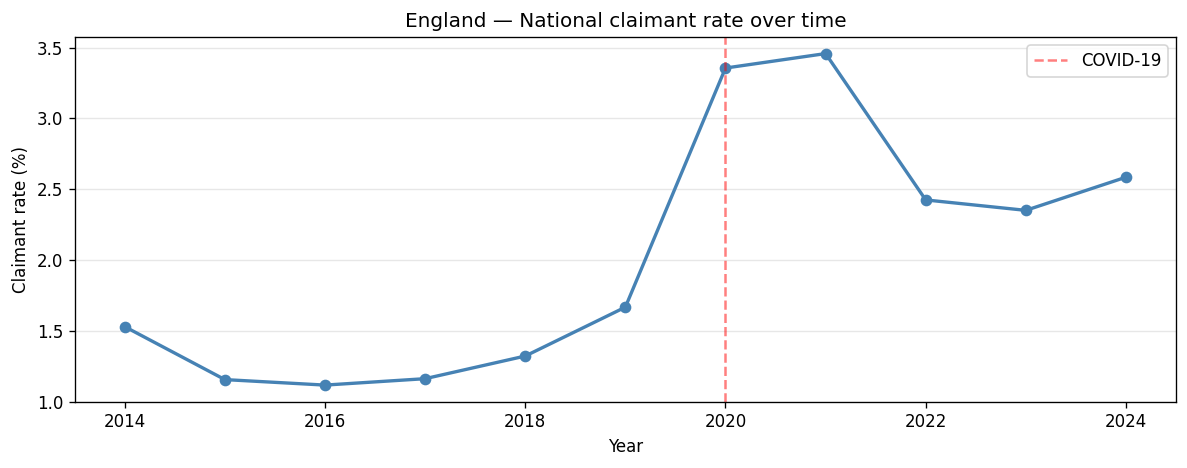

Claimant rate time series:
 year  claimant_rate
 2014       0.015286
 2015       0.011547
 2016       0.011160
 2017       0.011613
 2018       0.013212
 2019       0.016667
 2020       0.033564
 2021       0.034586
 2022       0.024244
 2023       0.023508
 2024       0.025850


In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cc_ts["year"], cc_ts["claimant_rate"] * 100, "o-", color="steelblue", linewidth=2)
ax.set_ylabel("Claimant rate (%)")
ax.set_xlabel("Year")
ax.set_title("England — National claimant rate over time")
ax.axvline(2020, color="red", linestyle="--", alpha=0.5, label="COVID-19")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

print("Claimant rate time series:")
print(cc_ts[["year", "claimant_rate"]].to_string(index=False))

### Crime: national total crime rate

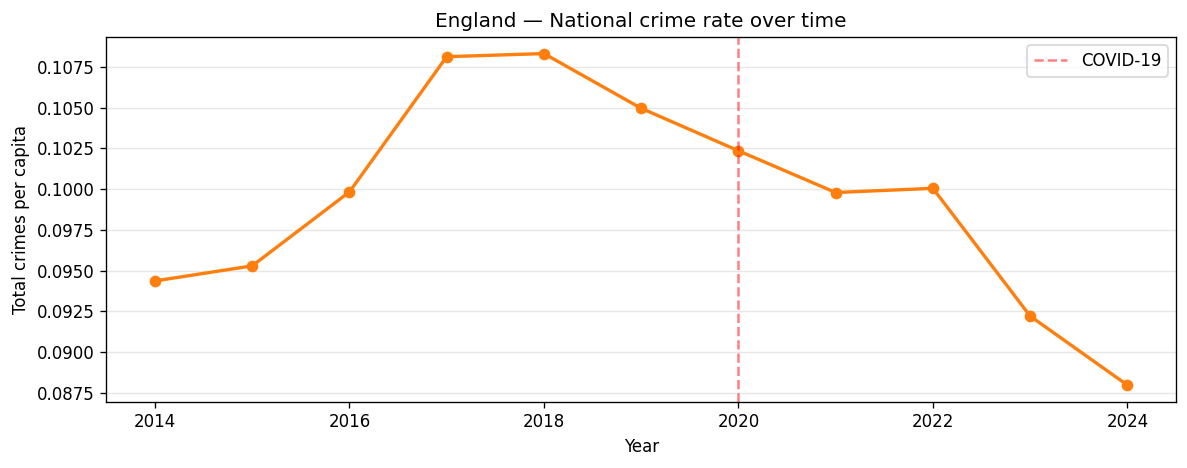

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(crime_ts["year"], crime_ts["total_crime_rate"], "o-", color="tab:orange", linewidth=2)
ax.set_ylabel("Total crimes per capita")
ax.set_xlabel("Year")
ax.set_title("England — National crime rate over time")
ax.axvline(2020, color="red", linestyle="--", alpha=0.5, label="COVID-19")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

### Health: selected disease prevalence rates

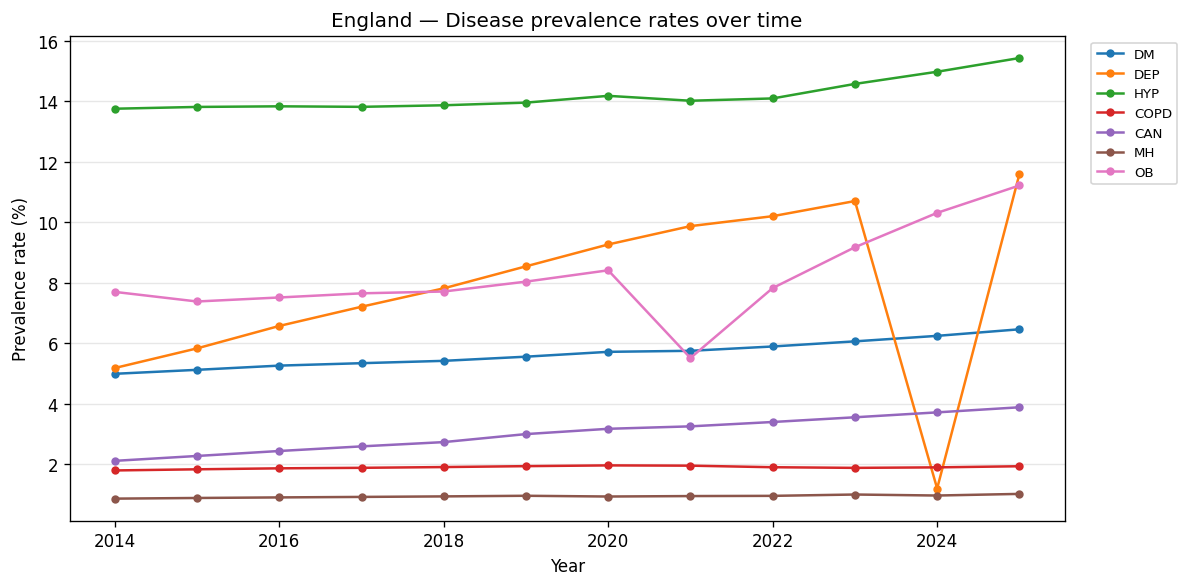

In [5]:
disease_cols = [c for c in health_ts.columns if c.endswith("_rate")]
fig, ax = plt.subplots(figsize=(10, 5))
for col in disease_cols:
    label = col.replace("_rate", "")
    ax.plot(health_ts["year"], health_ts[col] * 100, "o-", label=label, markersize=4)
ax.set_ylabel("Prevalence rate (%)")
ax.set_xlabel("Year")
ax.set_title("England — Disease prevalence rates over time")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## 2. Year-over-year change distributions at LSOA level

Compute the change in rate from year t to year t+1 for each LSOA.
The distribution should be roughly symmetric with most changes small.
Heavy tails suggest data quality issues.

In [6]:
lsoa_dir = out_dir / "lsoa"

# Claimant count: compute YoY changes
cc_files = sorted((lsoa_dir / "claimant_counts").glob("claimant_counts_*.csv"))
cc_yoy_changes = []

for i in range(len(cc_files) - 1):
    year_a = int(cc_files[i].stem.split("_")[-1])
    year_b = int(cc_files[i + 1].stem.split("_")[-1])
    df_a = pd.read_csv(cc_files[i])[["LSOA21CD", "claimant_count_rate"]].rename(
        columns={"claimant_count_rate": "rate_a"})
    df_b = pd.read_csv(cc_files[i + 1])[["LSOA21CD", "claimant_count_rate"]].rename(
        columns={"claimant_count_rate": "rate_b"})
    merged = df_a.merge(df_b, on="LSOA21CD")
    merged["change"] = merged["rate_b"] - merged["rate_a"]
    cc_yoy_changes.append({
        "period": f"{year_a}→{year_b}",
        "mean": merged["change"].mean(),
        "median": merged["change"].median(),
        "std": merged["change"].std(),
        "p1": merged["change"].quantile(0.01),
        "p99": merged["change"].quantile(0.99),
        "max_abs": merged["change"].abs().max(),
    })

cc_yoy_df = pd.DataFrame(cc_yoy_changes)
print("Claimant rate YoY changes (LSOA level):")
print(cc_yoy_df.to_string(index=False))

Claimant rate YoY changes (LSOA level):
   period      mean    median      std        p1       p99  max_abs
2014→2015 -0.003717 -0.002663 0.004074 -0.018642  0.001884 0.054107
2015→2016 -0.000391 -0.000259 0.002426 -0.007762  0.005852 0.024248
2016→2017  0.000454  0.000204 0.002714 -0.005464  0.009873 0.046219
2017→2018  0.001593  0.000960 0.003330 -0.004387  0.013389 0.042218
2018→2019  0.003408  0.002579 0.003887 -0.002964  0.016316 0.042219
2019→2020  0.016720  0.014856 0.008549  0.003893  0.042957 0.084692
2020→2021  0.000832  0.000000 0.004865 -0.008256  0.017207 0.050610
2021→2022 -0.010253 -0.008848 0.006517 -0.030000 -0.000367 0.060134
2022→2023 -0.000767 -0.000667 0.003444 -0.010153  0.007962 0.071026
2023→2024  0.002229  0.001581 0.004420 -0.006286  0.018464 0.103880


### Distribution of YoY claimant rate changes

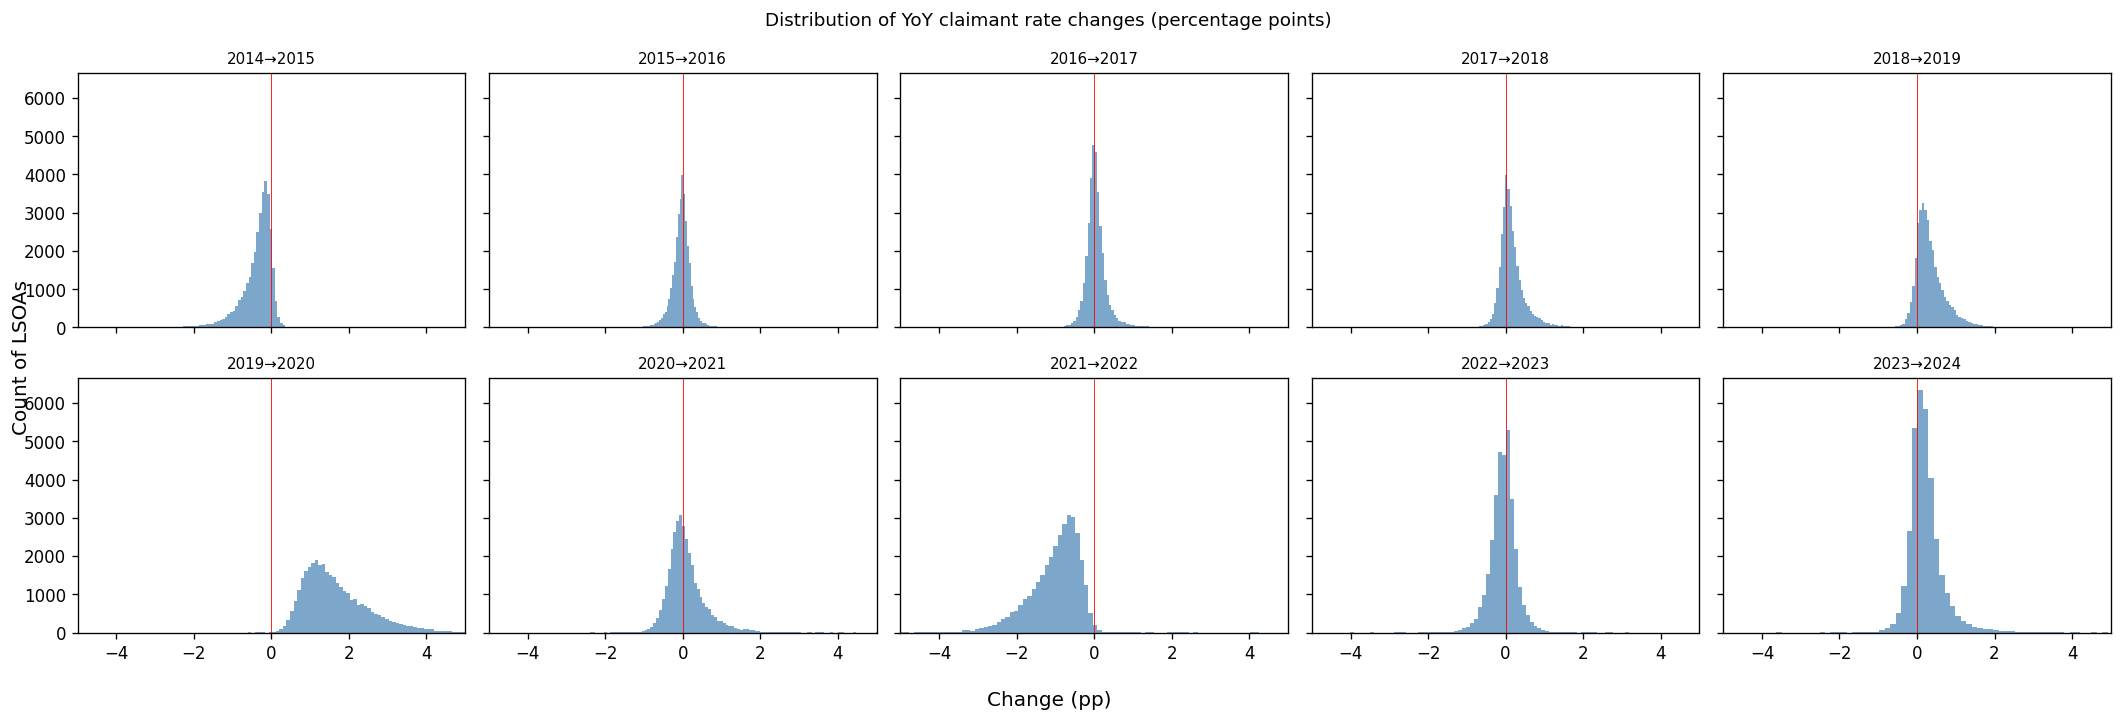

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharex=True, sharey=True)
axes = axes.flatten()

for idx in range(min(len(cc_files) - 1, 10)):
    year_a = int(cc_files[idx].stem.split("_")[-1])
    year_b = int(cc_files[idx + 1].stem.split("_")[-1])
    df_a = pd.read_csv(cc_files[idx])[["LSOA21CD", "claimant_count_rate"]].rename(
        columns={"claimant_count_rate": "rate_a"})
    df_b = pd.read_csv(cc_files[idx + 1])[["LSOA21CD", "claimant_count_rate"]].rename(
        columns={"claimant_count_rate": "rate_b"})
    merged = df_a.merge(df_b, on="LSOA21CD")
    change = merged["rate_b"] - merged["rate_a"]

    ax = axes[idx]
    ax.hist(change * 100, bins=100, color="steelblue", alpha=0.7, edgecolor="none")
    ax.set_title(f"{year_a}→{year_b}", fontsize=9)
    ax.axvline(0, color="red", linewidth=0.5)
    ax.set_xlim(-5, 5)

for idx in range(len(cc_files) - 1, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Distribution of YoY claimant rate changes (percentage points)", fontsize=11)
fig.supxlabel("Change (pp)")
fig.supylabel("Count of LSOAs")
fig.tight_layout()
plt.show()

## 3. Crime YoY stability

In [8]:
crime_files = sorted((lsoa_dir / "crime").glob("crime_*.csv"))
crime_yoy = []

for i in range(len(crime_files) - 1):
    year_a = int(crime_files[i].stem.split("_")[-1])
    year_b = int(crime_files[i + 1].stem.split("_")[-1])
    df_a = pd.read_csv(crime_files[i])
    df_b = pd.read_csv(crime_files[i + 1])

    count_cols_a = [c for c in df_a.columns
                    if c not in ("LSOA21CD", "LSOA21NM", "pop") and "_rate" not in c]
    count_cols_b = [c for c in df_b.columns
                    if c not in ("LSOA21CD", "LSOA21NM", "pop") and "_rate" not in c]
    df_a["total"] = df_a[count_cols_a].sum(axis=1)
    df_b["total"] = df_b[count_cols_b].sum(axis=1)
    df_a["rate"] = df_a["total"] / df_a["pop"].replace(0, np.nan)
    df_b["rate"] = df_b["total"] / df_b["pop"].replace(0, np.nan)

    merged = df_a[["LSOA21CD", "rate"]].merge(
        df_b[["LSOA21CD", "rate"]], on="LSOA21CD", suffixes=("_a", "_b"))
    change = merged["rate_b"] - merged["rate_a"]
    crime_yoy.append({
        "period": f"{year_a}→{year_b}",
        "mean": change.mean(),
        "std": change.std(),
        "p1": change.quantile(0.01),
        "p99": change.quantile(0.99),
    })

print("Total crime rate YoY changes:")
print(pd.DataFrame(crime_yoy).to_string(index=False))

Total crime rate YoY changes:
   period      mean      std        p1      p99
2014→2015  0.000356 0.024840 -0.061121 0.061431
2015→2016  0.004037 0.023258 -0.053057 0.069533
2016→2017  0.007732 0.025357 -0.046755 0.087378
2017→2018 -0.000347 0.025600 -0.070709 0.066009
2018→2019 -0.003662 0.038249 -0.109223 0.060884
2019→2020 -0.002231 0.057265 -0.154086 0.070151
2020→2021 -0.002608 0.025257 -0.065464 0.069533
2021→2022 -0.000163 0.039039 -0.069908 0.092828
2022→2023 -0.008422 0.048431 -0.143279 0.074508
2023→2024 -0.004598 0.032449 -0.096384 0.071105


## 4. Outlier detection — extreme YoY changes

Flag LSOAs where the claimant rate changed by more than 10 percentage
points in a single year (highly unusual for small-area data).

In [9]:
extreme_changes = []

for i in range(len(cc_files) - 1):
    year_a = int(cc_files[i].stem.split("_")[-1])
    year_b = int(cc_files[i + 1].stem.split("_")[-1])
    df_a = pd.read_csv(cc_files[i])[["LSOA21CD", "LSOA21NM", "claimant_count_rate", "pop"]].rename(
        columns={"claimant_count_rate": "rate_a"})
    df_b = pd.read_csv(cc_files[i + 1])[["LSOA21CD", "claimant_count_rate"]].rename(
        columns={"claimant_count_rate": "rate_b"})
    merged = df_a.merge(df_b, on="LSOA21CD")
    merged["change_pp"] = (merged["rate_b"] - merged["rate_a"]) * 100
    outliers = merged[merged["change_pp"].abs() > 10].copy()
    outliers["period"] = f"{year_a}→{year_b}"
    if len(outliers) > 0:
        extreme_changes.append(outliers[["period", "LSOA21CD", "LSOA21NM", "pop",
                                          "rate_a", "rate_b", "change_pp"]])

if extreme_changes:
    all_extreme = pd.concat(extreme_changes)
    print(f"LSOAs with claimant rate change > 10pp: {len(all_extreme)}")
    print(all_extreme.sort_values("change_pp", key=abs, ascending=False).head(20).to_string(index=False))
else:
    print("No LSOAs with claimant rate change > 10pp.")

LSOAs with claimant rate change > 10pp: 1
   period  LSOA21CD            LSOA21NM    pop   rate_a   rate_b  change_pp
2023→2024 E01022273 Forest of Dean 010C 1452.0 0.007748 0.111628  10.387971


## 5. Cross-domain national trends overlay

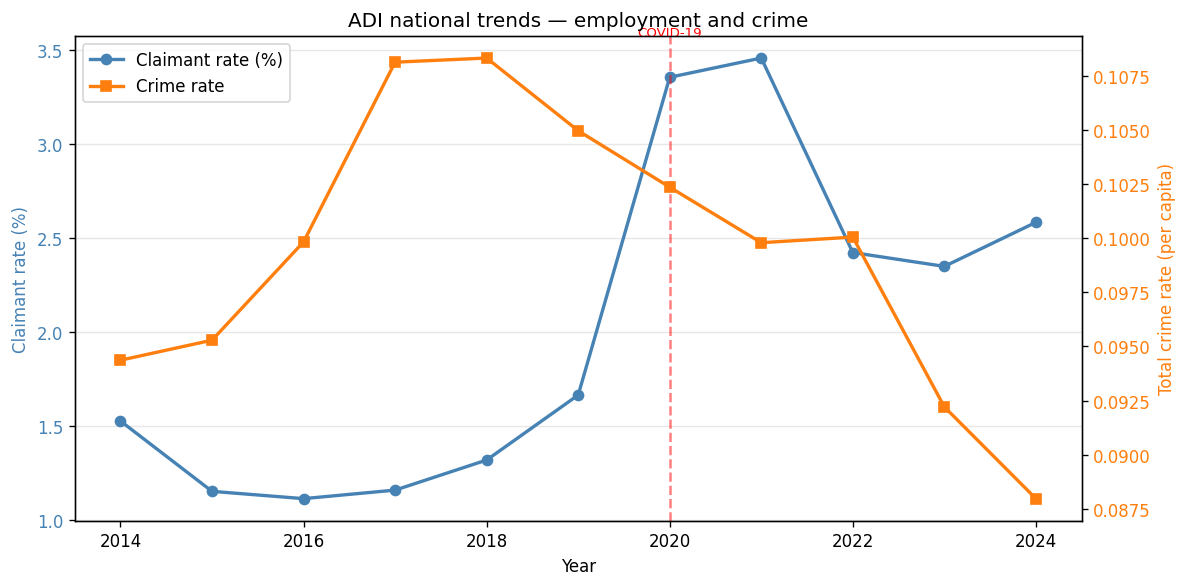

In [10]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = "steelblue"
ax1.plot(cc_ts["year"], cc_ts["claimant_rate"] * 100, "o-", color=color1, linewidth=2, label="Claimant rate (%)")
ax1.set_ylabel("Claimant rate (%)", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
color2 = "tab:orange"
ax2.plot(crime_ts["year"], crime_ts["total_crime_rate"], "s-", color=color2, linewidth=2, label="Crime rate")
ax2.set_ylabel("Total crime rate (per capita)", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

ax1.axvline(2020, color="red", linestyle="--", alpha=0.5)
ax1.annotate("COVID-19", xy=(2020, ax1.get_ylim()[1]), fontsize=8, color="red", ha="center")

ax1.set_xlabel("Year")
ax1.set_title("ADI national trends — employment and crime")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## Interpretation

**What to look for:**
- The 2020 claimant rate should spike sharply (COVID-19 pandemic)
- Crime should dip around 2020 (lockdowns reduced street crime)
- Health prevalence rates should trend slowly and smoothly (chronic
  disease burden doesn't change rapidly year to year)
- YoY change distributions should be tight and symmetric; heavy tails
  or bimodality suggest data joining issues
- Extreme outliers (>10pp) are almost always small-population LSOAs
  where a handful of claimants cause large rate swings